In [1]:
import numpy 
import matplotlib.pyplot as plt
import pandas
import math
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [2]:
dataframe=pandas.read_csv(r"C:\Users\asus\Downloads\Deeplearningdataset\airline-passengers.csv",usecols=[1],engine='python')
dataset=dataframe.values
dataset=dataset.astype("float32")
scaler=MinMaxScaler(feature_range=(0,1))
dataset=scaler.fit_transform(dataset)

In [3]:
train_size=int(len(dataset)*0.67)
test_size=len(dataset)-train_size
train,test=dataset[0:train_size,:],dataset[train_size:len(dataset),:]
print(len(train),len(test))

96 48


In [4]:
def create_dataset(dataset,look_back=1):
    dataX,dataY=[],[]
    for i in range(len(dataset)-look_back-1):
        a=dataset[i:(i+look_back),0]
        dataX.append(a)
        dataY.append(dataset[i+look_back,0])
    return numpy.array(dataX),numpy.array(dataY)

In [5]:
look_back=1
trainX,trainY=create_dataset(train,look_back)
testX,testY=create_dataset(test,look_back)
trainX=numpy.reshape(trainX,(trainX.shape[0],1,trainX.shape[1]))
testX=numpy.reshape(testX,(testX.shape[0],1,testX.shape[1]))

In [6]:
print(trainX.shape)

(94, 1, 1)


In [7]:
model=Sequential()
model.add(LSTM(4,input_shape=(1,look_back)))
model.add(Dense(1))
model.compile(loss="mean_squared_error",optimizer="adam")
model.fit(trainX,trainY,epochs=100,batch_size=1,verbose=2)

C:\Users\asus\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
94/94 - 5s - 58ms/step - loss: 0.0470
Epoch 2/100
94/94 - 1s - 6ms/step - loss: 0.0229
Epoch 3/100
94/94 - 1s - 6ms/step - loss: 0.0175
Epoch 4/100
94/94 - 1s - 6ms/step - loss: 0.0158
Epoch 5/100
94/94 - 1s - 6ms/step - loss: 0.0147
Epoch 6/100
94/94 - 1s - 6ms/step - loss: 0.0140
Epoch 7/100
94/94 - 1s - 6ms/step - loss: 0.0129
Epoch 8/100
94/94 - 1s - 7ms/step - loss: 0.0120
Epoch 9/100
94/94 - 1s - 6ms/step - loss: 0.0111
Epoch 10/100
94/94 - 1s - 6ms/step - loss: 0.0102
Epoch 11/100
94/94 - 1s - 6ms/step - loss: 0.0093
Epoch 12/100
94/94 - 1s - 6ms/step - loss: 0.0084
Epoch 13/100
94/94 - 1s - 6ms/step - loss: 0.0075
Epoch 14/100
94/94 - 1s - 6ms/step - loss: 0.0068
Epoch 15/100
94/94 - 1s - 6ms/step - loss: 0.0060
Epoch 16/100
94/94 - 1s - 9ms/step - loss: 0.0053
Epoch 17/100
94/94 - 1s - 7ms/step - loss: 0.0047
Epoch 18/100
94/94 - 1s - 7ms/step - loss: 0.0041
Epoch 19/100
94/94 - 1s - 7ms/step - loss: 0.0037
Epoch 20/100
94/94 - 1s - 6ms/step - loss: 0.0033
Epoch 21

In [8]:
print(trainY.shape)
print(testY.shape)

(94,)
(46,)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


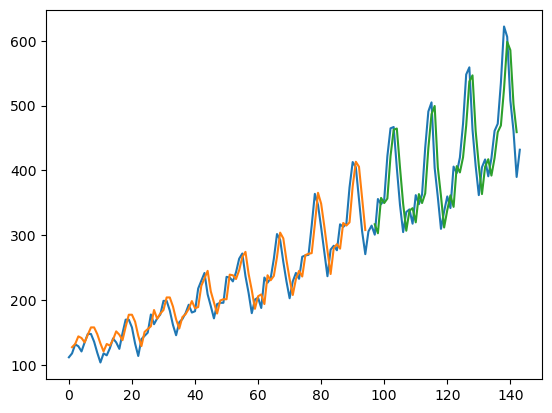

In [9]:
trainpredict=model.predict(trainX)
testpredict=model.predict(testX)
trainpredict=scaler.inverse_transform(trainpredict)
trainY=scaler.inverse_transform([trainY])
testpredict=scaler.inverse_transform(testpredict)
testY=scaler.inverse_transform([testY])
trainScore=math.sqrt(mean_squared_error(trainY[0],trainpredict[:,0]))
testScore=math.sqrt(mean_squared_error(testY[0],testpredict[:,0]))
trainpredictplot=numpy.empty_like(dataset)
trainpredictplot[:,:]=numpy.nan
trainpredictplot[look_back:len(trainpredict)+look_back,:]=trainpredict
testpredictplot=numpy.empty_like(dataset)
testpredictplot[:,:]=numpy.nan
testpredictplot[len(trainpredict)+(look_back*2)+1:len(dataset)-1,:]=testpredict
plt.plot(scaler.inverse_transform(dataset))
plt.plot(trainpredictplot)
plt.plot(testpredictplot)
plt.show()

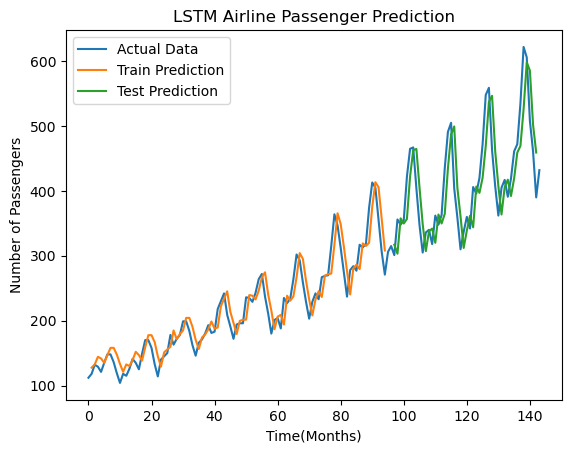

In [13]:
plt.plot(scaler.inverse_transform(dataset),label="Actual Data")
plt.plot(trainpredictplot,label="Train Prediction")
plt.plot(testpredictplot,label="Test Prediction")
plt.xlabel("Time(Months)")
plt.ylabel("Number of Passengers")
plt.title("LSTM Airline Passenger Prediction")
plt.legend()
plt.show()